<a href="https://colab.research.google.com/github/kojeda603/analisis_exploratorio_de_datos/blob/main/PARCIAL_FINAL_KEVIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Fertilidad de Suelos en Colombia (AGROSAVIA)

**Curso:** Análisis Exploratorio de Datos — Tarea individual (etapa final)
**Fuente:** Laboratorio de Química y Física de Suelos AGROSAVIA — datos.gov.co
**Dataset:** `Resultados_de_Análisis_de_Laboratorio_Suelos_en_Colombia_20260510.csv`

Este notebook desarrolla los **cuatro pasos obligatorios** de la guía:
1. Carga, inspección y tipado (con tratamiento documentado de valores no numéricos).
2. Distribuciones de parámetros de fertilidad.
3. Análisis espacial y por cultivo.
4. Relaciones entre nutrientes.



In [119]:
# ---- Setup ----
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ciencia_de_datos/Resultados_de_Análisis_de_Laboratorio_Suelos_en_Colombia_20260510.csv")

pd.set_option('display.max_columns', None)   # Mostrar TODAS las columnas
pd.set_option('display.width', None)         # Sin límite de ancho
pd.set_option('display.max_colwidth', None)  # No cortar contenido de celdas

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_5005/3351325563.py:12: DtypeWarning: Columns (11,12,13,14,17,18,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ciencia_de_datos/Resultados_de_Análisis_de_Laboratorio_Suelos_en_Colombia_20260510.csv")


## Paso 1 — Carga, inspección y tipado


### 1.1. Dimensiones, tipos de dato y porcentaje de nulos por columna

In [120]:
# Dimensiones
print("Dimensiones:", df.shape)
df.head(5)

Dimensiones: (92738, 32)


,Secuencial,Fecha de Análisis,Departamento,Municipio,Cultivo,Estado,Tiempo de establecimiento,Topografia,Drenaje,Riego,Fertilizantes aplicados,pH agua:suelo,Materia organica,Fósforo Bray II,Azufre Fosfato monocalcico,Acidez Intercambiable,Aluminio intercambiable,Calcio intercambiable,Magnesio intercambiable,Potasio intercambiable,Sodio intercambiable,capacidad de intercambio cationico,Conductividad electrica,Hierro disponible olsen,Cobre disponible,Manganeso disponible Olsen,Zinc disponible Olsen,Boro disponible,Hierro disponible doble acido,Cobre disponible doble acido,Manganeso disponible doble acido,Zinc disponible doble acido
0,1.0,7/01/2014,NARIÑO,SAN ANDRÉS DE TUMACO,No Indica,No indica,No indica,No indica,No indica,No indica,No indica,5.64,3.889,6.482,8.384,ND,ND,1.541,0.38,0.118,0.054,2.094,0.133,66.39,1.700,1.700,1.5,0.187,ND,ND,ND,ND
1,2.0,21/08/2014,HUILA,SANTA MARÍA,Granadilla,Establecido,De 1 a 5 años,Pendiente,Buen drenaje,No Tiene,No indica,4.24,2.287,520.1,90.3,2.021,1.483,2.932,0.925,2.131,0.043,8.054,2.749,250.9,3.7,29.4,28.70,2.084,ND,ND,ND,ND
2,3.0,22/08/2014,ANTIOQUIA,LIBORINA,Café,Por establecer,No indica,Pendiente,Mal drenaje,No Tiene,PRODUCCION,5.22,2.518,58.11,2.686,0.955,0.796,3.818,1.11,<0.09,0.01,5.985,0.328,390,11.10,8.299,5,0.085,ND,ND,ND,ND
3,4.0,22/08/2014,ANTIOQUIA,LIBORINA,Maracuyá,Por establecer,No indica,Ondulado,Mal drenaje,No Tiene,No indica,5.45,2.841,4.583,1.782,0,0,4.754,3.577,0.118,0.01,8.461,0.171,200,4.2,4.699,1,0.229,ND,ND,ND,ND
4,5.0,22/08/2014,ANTIOQUIA,LIBORINA,Café,Por establecer,No indica,Ondulado,Mal drenaje,No Tiene,PRODUCCION,5.43,2.703,5.512,3.138,0.150,0.109,7.338,3.022,0.096,0.032,10.64,0.323,117.9,3.8,4.600,0.700,0.139,ND,ND,ND,ND


In [121]:
#Nombre de columnas
df.columns

Index(['Secuencial', 'Fecha de Análisis', 'Departamento', 'Municipio',
       'Cultivo', 'Estado', 'Tiempo de establecimiento', 'Topografia',
       'Drenaje', 'Riego', 'Fertilizantes aplicados', 'pH agua:suelo',
       'Materia organica', 'Fósforo Bray II', 'Azufre Fosfato monocalcico',
       'Acidez Intercambiable', 'Aluminio intercambiable',
       'Calcio intercambiable', 'Magnesio intercambiable',
       'Potasio intercambiable', 'Sodio intercambiable',
       'capacidad de intercambio cationico', 'Conductividad electrica',
       'Hierro disponible olsen', 'Cobre disponible',
       'Manganeso disponible Olsen', 'Zinc disponible Olsen',
       'Boro disponible', 'Hierro disponible doble acido',
       'Cobre disponible doble acido', 'Manganeso disponible doble acido',
       'Zinc disponible doble  acido'],
      dtype='object')

In [122]:
#Verificacion de las variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92738 entries, 0 to 92737
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Secuencial                          92738 non-null  float64
 1   Fecha de Análisis                   92738 non-null  object 
 2   Departamento                        92738 non-null  object 
 3   Municipio                           92736 non-null  object 
 4   Cultivo                             92738 non-null  object 
 5   Estado                              92738 non-null  object 
 6   Tiempo de establecimiento           92738 non-null  object 
 7   Topografia                          92738 non-null  object 
 8   Drenaje                             92738 non-null  object 
 9   Riego                               92738 non-null  object 
 10  Fertilizantes aplicados             92738 non-null  object 
 11  pH agua:suelo                       92738

In [123]:
# Columnas NO numéricas:
no_numericas = ['Secuencial', 'Fecha de Análisis', 'Departamento', 'Municipio',
                'Cultivo', 'Estado', 'Tiempo de establecimiento', 'Topografia',
                'Drenaje', 'Riego', 'Fertilizantes aplicados']

# El resto SÍ son numéricas
num_cols = [c for c in df.columns if c not in no_numericas]

print(num_cols)

['pH agua:suelo', 'Materia organica', 'Fósforo Bray II', 'Azufre Fosfato monocalcico', 'Acidez Intercambiable', 'Aluminio intercambiable', 'Calcio intercambiable', 'Magnesio intercambiable', 'Potasio intercambiable', 'Sodio intercambiable', 'capacidad de intercambio cationico', 'Conductividad electrica', 'Hierro disponible olsen', 'Cobre disponible', 'Manganeso disponible Olsen', 'Zinc disponible Olsen', 'Boro disponible', 'Hierro disponible doble acido', 'Cobre disponible doble acido', 'Manganeso disponible doble acido', 'Zinc disponible doble \xa0acido']


In [124]:

df.columns = df.columns.str.replace("\xa0", " ", regex=False).str.replace(r"\s+", " ", regex=True).str.strip()

#Columnas relevantes para la limpieza
num_cols = ['pH agua:suelo',
       'Materia organica', 'Fósforo Bray II', 'Azufre Fosfato monocalcico',
       'Acidez Intercambiable', 'Aluminio intercambiable',
       'Calcio intercambiable', 'Magnesio intercambiable',
       'Potasio intercambiable', 'Sodio intercambiable',
       'capacidad de intercambio cationico', 'Conductividad electrica',
       'Hierro disponible olsen', 'Cobre disponible',
       'Manganeso disponible Olsen', 'Zinc disponible Olsen',
       'Boro disponible', 'Hierro disponible doble acido',
       'Cobre disponible doble acido', 'Manganeso disponible doble acido',
       'Zinc disponible doble acido']

In [125]:
#DataFrame con la columna, total de valores sucios y los 3 valores mas repetidos
filas = []
for c in num_cols:
    sucios = df[pd.to_numeric(df[c], errors="coerce").isna()][c].dropna()
    top = sucios.value_counts().head(3)
    ejemplos = ", ".join(f"{v} ({n})" for v, n in top.items())
    filas.append({"columna": c, "total_sucios": len(sucios), "top_3": ejemplos})

resumen_sucios = pd.DataFrame(filas)
resumen_sucios

,columna,total_sucios,top_3
0,pH agua:suelo,11,"<3.80 (6), >10.00 (4), 4..01 (1)"
1,Materia organica,73,"<0.38 (69), ND (2), >44.82 (2)"
2,Fósforo Bray II,15033,"<3.87 (11366), <1.29 (2097), ND (1469)"
3,Azufre Fosfato monocalcico,1562,"ND (1499), <0.01 (61), <2.50 (2)"
4,Acidez Intercambiable,45130,ND (45130)
5,Aluminio intercambiable,45130,ND (45130)
6,Calcio intercambiable,5170,"<1.12 (2340), < 0.5 (1592), <0.59 (1232)"
7,Magnesio intercambiable,3875,<0.20 (3875)
8,Potasio intercambiable,15167,<0.09 (15167)
9,Sodio intercambiable,44774,"<0.14 (33005), < 0.1 (11763), < 0.0 (6)"


### 1.2. Conversión de variables numéricas almacenadas como texto (p. ej. pH, materia orgánica): documentar el procedimiento y los valores no convertibles

In [126]:
#DataFrame basado en los 3 valores mas repetidos para conocer a cual pertenece

filas = []
for c in num_cols:
    serie = df[c].astype(str).str.strip()

    filas.append({
        "columna":       c,
        "ND/No indica":  serie.isin(["ND", "NA", "No indica", ""]).sum(),
        "<LOD (\"<x\")": serie.str.startswith("<").sum(),
        ">max (\">x\")": serie.str.startswith(">").sum(),
        "coma decimal":  serie.str.contains(",", na=False).sum(),
        "negativos":     serie.str.startswith("-").sum(),

    })

doc = pd.DataFrame(filas).set_index("columna")
doc

,ND/No indica,"<LOD (""<x"")",">max ("">x"")",coma decimal,negativos
columna,,,,,
pH agua:suelo,0,6,4,0,0
Materia organica,2,69,2,0,0
Fósforo Bray II,1469,13564,0,0,0
Azufre Fosfato monocalcico,1499,63,0,0,1
Acidez Intercambiable,45130,0,0,0,0
Aluminio intercambiable,45130,0,0,0,0
Calcio intercambiable,0,5170,0,0,0
Magnesio intercambiable,0,3875,0,0,0
Potasio intercambiable,0,15167,0,0,0


In [127]:
#Funcion para la limpieza de los datos
def limpiar_numerico(serie):
    serie = serie.astype(str).str.strip()
    serie = serie.replace({"ND": np.nan, "No indica": np.nan, "NA": np.nan, "": np.nan})
    serie = serie.str.replace(" ", "", regex=False)   # quita espacios internos
    serie = serie.str.replace(",", ".", regex=False)  # coma decimal → punto

    # Marca cuáles eran "<x" antes de quitarles el símbolo
    mask_lod = serie.str.startswith("<", na=False)
    serie = serie.str.lstrip("<>")                    # quita < o > del inicio

    out = pd.to_numeric(serie, errors="coerce")       # convierte; lo no pasable → NaN
    out = out.mask(mask_lod, out / 2)                 # <x → x/2 (mitad del LOD)
    out = out.mask(out < 0.00001, np.nan)                   # negativos → NaN (no tienen sentido físico)

    return out

In [128]:
for c in num_cols:
    df[c] = limpiar_numerico(df[c])

In [129]:
#Validacion de la limpieza
filas = []
for c in num_cols:
    serie = df[c].astype(str).str.strip()
    filas.append({
        "columna":       c,
        "ND/No indica":  serie.isin(["ND", "NA", "No indica", ""]).sum(),
        "<LOD (\"<x\")": serie.str.startswith("<").sum(),
        ">max (\">x\")": serie.str.startswith(">").sum(),
        "coma decimal":  serie.str.contains(",", na=False).sum(),
        "negativos":     serie.str.startswith("-").sum(),
        "NaN final":     df[c].isna().sum(),
    })

doc = pd.DataFrame(filas).set_index("columna")
doc

,ND/No indica,"<LOD (""<x"")",">max ("">x"")",coma decimal,negativos,NaN final
columna,,,,,,
pH agua:suelo,0,0,0,0,0,1
Materia organica,0,0,0,0,0,3
Fósforo Bray II,0,0,0,0,0,1469
Azufre Fosfato monocalcico,0,0,0,0,0,1500
Acidez Intercambiable,0,0,0,0,0,45732
Aluminio intercambiable,0,0,0,0,0,48047
Calcio intercambiable,0,0,0,0,0,0
Magnesio intercambiable,0,0,0,0,0,0
Potasio intercambiable,0,0,0,0,0,0


In [130]:
#Validacion de la limpieza
df[num_cols].dtypes

,0
pH agua:suelo,float64
Materia organica,float64
Fósforo Bray II,float64
Azufre Fosfato monocalcico,float64
Acidez Intercambiable,float64
Aluminio intercambiable,float64
Calcio intercambiable,float64
Magnesio intercambiable,float64
Potasio intercambiable,float64
Sodio intercambiable,float64


In [131]:
#DataFrame con valores no nulos, nulos y su porcentaje
faltantes = pd.DataFrame({
    "no nulos":  df[num_cols].notna().sum(),
    "nulos":     df[num_cols].isna().sum(),
    "% nulos":   (df[num_cols].isna().mean() * 100).round(2),
}).sort_values("% nulos", ascending=False)

faltantes

,no nulos,nulos,% nulos
Zinc disponible doble acido,4779,87959,94.85
Hierro disponible doble acido,4786,87952,94.84
Manganeso disponible doble acido,4786,87952,94.84
Cobre disponible doble acido,4786,87952,94.84
Aluminio intercambiable,44691,48047,51.81
Acidez Intercambiable,47006,45732,49.31
Zinc disponible Olsen,86856,5882,6.34
Cobre disponible,86864,5874,6.33
Hierro disponible olsen,86866,5872,6.33
Manganeso disponible Olsen,86866,5872,6.33


### 1.3. Descripción estadística básica

In [132]:
# Descripción estadística básica
desc = df[num_cols].describe().T
desc["mediana"] = df[num_cols].median()
desc = desc[["count", "mean", "mediana", "std", "min", "25%", "75%", "max"]]
desc.columns = ["n", "media", "mediana", "desv_std", "min", "p25", "p75", "max"]
desc.round(3)

,n,media,mediana,desv_std,min,p25,p75,max
pH agua:suelo,92737.0,5.708,5.470,1.021,1.900,4.960,6.260,10.57
Materia organica,92735.0,4.409,2.750,4.597,0.010,1.675,5.127,75.04
Fósforo Bray II,91269.0,28.705,8.403,74.550,0.088,3.061,26.180,3015.00
Azufre Fosfato monocalcico,91238.0,14.255,6.202,56.070,0.005,3.735,11.320,4862.00
Acidez Intercambiable,47006.0,2.329,1.720,2.347,0.010,0.860,2.970,40.89
Aluminio intercambiable,44691.0,1.975,1.419,2.037,0.008,0.690,2.540,36.60
Calcio intercambiable,92738.0,7.387,4.130,9.411,0.028,1.412,9.609,171.80
Magnesio intercambiable,92738.0,2.040,1.020,2.744,0.006,0.400,2.480,68.52
Potasio intercambiable,92738.0,0.368,0.220,0.706,0.045,0.118,0.423,64.06
Sodio intercambiable,92731.0,0.218,0.070,0.945,0.002,0.070,0.166,99.11


### 1.4. Identificación de registros con valores fuera de rango agronómicamente plausible y su respectiva limpieza

In [133]:
# Valores fuera de rango agronómicamente plausible

plausible = {
    # --- Generales ---
    "pH agua:suelo":                       (3.5, 10.5),   # adim.
    "Materia organica":                    (0,    30),    # % (Histosoles fuera)
    "Conductividad electrica":             (0,    30),    # dS/m

    # --- Macronutrientes / acidez ---
    "Fósforo Bray II":                     (0,    300),   # mg/kg
    "Azufre Fosfato monocalcico":          (0,    150),   # mg/kg (S-SO4 disponible)
    "Acidez Intercambiable":               (0,    25),    # cmol/kg
    "Aluminio intercambiable":             (0,    20),    # cmol/kg

    # --- Bases intercambiables y CIC ---
    "Calcio intercambiable":               (0,    80),    # cmol/kg
    "Magnesio intercambiable":             (0,    25),    # cmol/kg
    "Potasio intercambiable":              (0,    5),     # cmol/kg
    "Sodio intercambiable":                (0,    15),    # cmol/kg
    "capacidad de intercambio cationico":  (0,    80),    # cmol/kg

    # --- Micronutrientes Olsen / Olsen-EDTA ---
    "Hierro disponible olsen":             (0,    3000),   # mg/kg
    "Cobre disponible":                    (0,    60),    # mg/kg
    "Manganeso disponible Olsen":          (0,    300),   # mg/kg
    "Zinc disponible Olsen":               (0,    80),    # mg/kg
    "Boro disponible":                     (0,    10),    # mg/kg

    # --- Micronutrientes doble ácido (Mehlich) ---
    # Mehlich extrae más que Olsen, especialmente en suelos ácidos
    "Hierro disponible doble acido":       (0,    500),   # mg/kg
    "Cobre disponible doble acido":        (0,    50),    # mg/kg
    "Manganeso disponible doble acido":    (0,    300),   # mg/kg
    "Zinc disponible doble acido":        (0,    80),    # mg/kg  (ojo: doble espacio en el nombre)
}


oor = []
for c, (lo, hi) in plausible.items():
    mask = ((df[c] < lo) | (df[c] > hi))
    oor.append((c, lo, hi, int(mask.sum())))

pd.DataFrame(oor, columns=["variable", "min_plaus", "max_plaus", "n_fuera_rango"])

,variable,min_plaus,max_plaus,n_fuera_rango
0,pH agua:suelo,3.5,10.5,14
1,Materia organica,0.0,30.0,192
2,Conductividad electrica,0.0,30.0,14
3,Fósforo Bray II,0.0,300.0,1016
4,Azufre Fosfato monocalcico,0.0,150.0,1037
5,Acidez Intercambiable,0.0,25.0,32
6,Aluminio intercambiable,0.0,20.0,44
7,Calcio intercambiable,0.0,80.0,52
8,Magnesio intercambiable,0.0,25.0,32
9,Potasio intercambiable,0.0,5.0,149


## Paso 2 — Distribuciones de parámetros de fertilidad

### 2.1 Histogramas

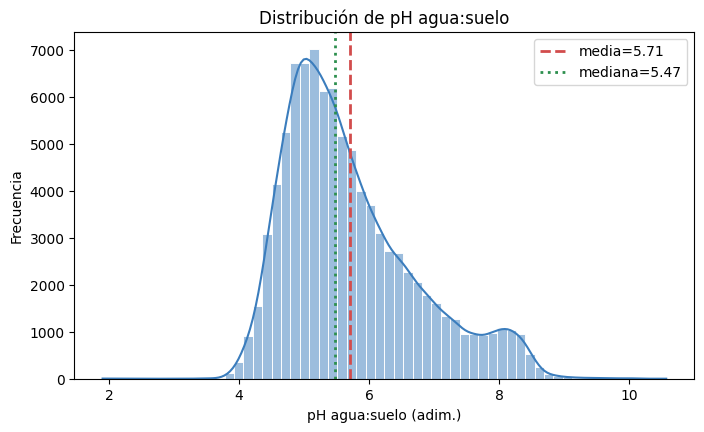

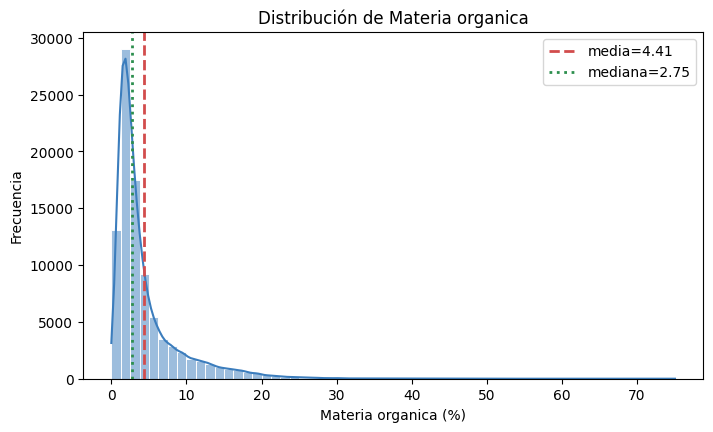

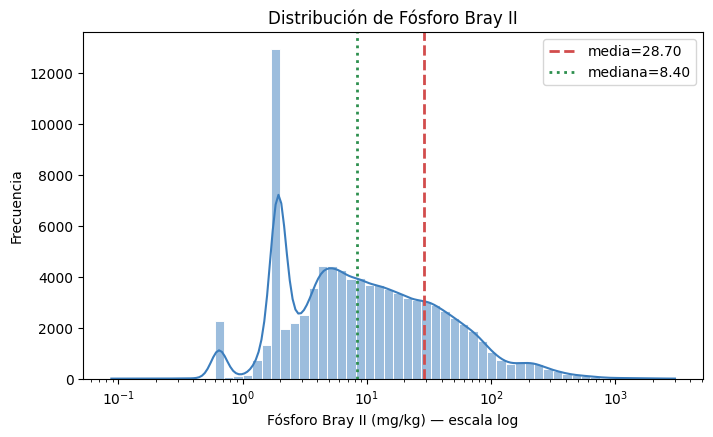

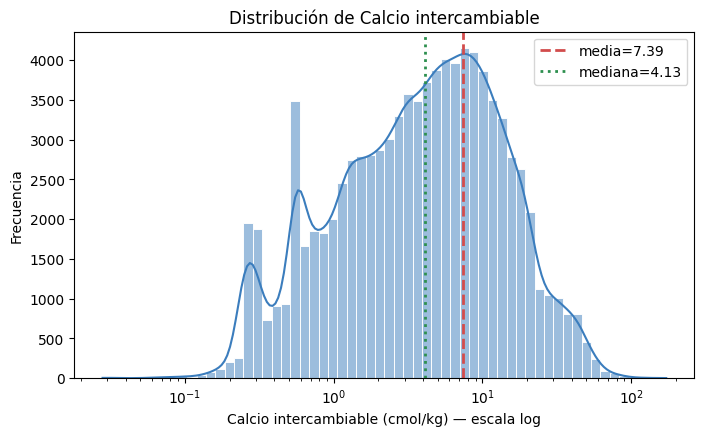

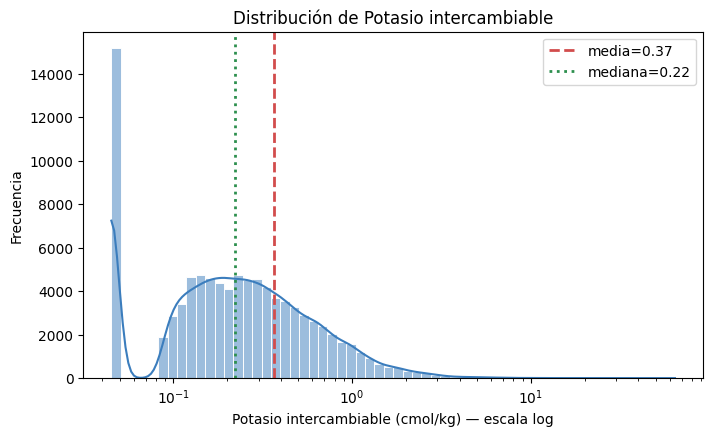

In [134]:
def hist(col, bins=50, log=False, unit=""):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    data = df[col].dropna()

    sns.histplot(data, bins=bins, kde=True, color="#3b7dbd",
                 edgecolor="white", ax=ax, log_scale=log)

    ax.axvline(data.mean(),   color="#d24c4c", lw=2, ls="--",
               label=f"media={data.mean():.2f}")
    ax.axvline(data.median(), color="#2d8f4e", lw=2, ls=":",
               label=f"mediana={data.median():.2f}")

    ax.set_xlabel(f"{col} ({unit})" + (" — escala log" if log else ""))
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de {col}")
    ax.legend()
    plt.show()

hist("pH agua:suelo",          bins=60, unit="adim.")
hist("Materia organica",       bins=60, unit="%")
hist("Fósforo Bray II",        bins=60, log=True, unit="mg/kg")
hist("Calcio intercambiable",  bins=60, log=True, unit="cmol/kg")
hist("Potasio intercambiable", bins=60, log=True, unit="cmol/kg")



### Patrones cruzados

1. **Suelos ácidos + P bajo + K bajo + MO baja** → perfil típico de suelos tropicales lavados/degradados, coherente con la geografía agrícola colombiana (Andes, Llanos, zona cafetera).

2. **Media > mediana en todas las variables nutricionales** → se confirma que la **mediana** es el estadístico de referencia para reportar tendencia central en este conjunto.

### Conclusión del Paso 2

Las distribuciones revelan suelos colombianos mayormente **ácidos (pH mediana 5.47)**, con **materia orgánica baja (2.75 %)** y **deficiencias nutricionales en P y K**. El calcio se mantiene en niveles adecuados en la mayoría de los registros. Todas las variables nutricionales presentan fuerte asimetría positiva, por lo que la **mediana** es el estadístico de tendencia central recomendado.

### 2.2. Clasificación de los suelos según rangos estándar de pH (muy ácido, ácido, neutro, alcalino, muy alcalino) y análisis de su frecuencia.

In [135]:
bins   = [-np.inf, 4.5, 5.5, 6.5, 7.5, 8.5, np.inf]
labels = ["Muy ácido", "Ácido", "Lig. ácido", "Neutro", "Alcalino", "Muy alcalino"]

df["clase_pH"] = pd.cut(
    df["pH agua:suelo"],
    bins=bins,
    labels=labels,
    right=False,   # intervalos [lo, hi)
    ordered=True
)

resumen_ph = (df["clase_pH"]
              .value_counts()
              .reindex(labels)
              .to_frame("n"))
resumen_ph["pct"] = (100 * resumen_ph["n"] / resumen_ph["n"].sum()).round(2)
resumen_ph

,n,pct
clase_pH,,
Muy ácido,5802,6.26
Ácido,41611,44.87
Lig. ácido,26519,28.60
Neutro,11534,12.44
Alcalino,6588,7.10
Muy alcalino,683,0.74


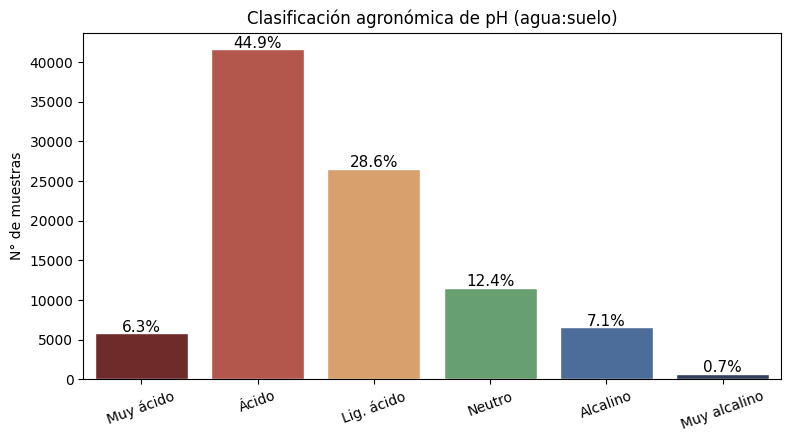

In [136]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#7a1f1f", "#c44a3b", "#e9a05a", "#5fa86a", "#3f6aa6", "#293c66"]

sns.barplot(
    x=resumen_ph.index, y=resumen_ph["n"],
    hue=resumen_ph.index, palette=colors,
    ax=ax, edgecolor="white", legend=False   # ← clave
)

for i, (n, p) in enumerate(zip(resumen_ph["n"], resumen_ph["pct"])):
    ax.text(i, n + 200, f"{p:.1f}%", ha="center", fontsize=11)

ax.set_ylabel("N° de muestras")
ax.set_xlabel("")
ax.set_title("Clasificación agronómica de pH (agua:suelo)")
ax.tick_params(axis="x", rotation=20)
plt.show()

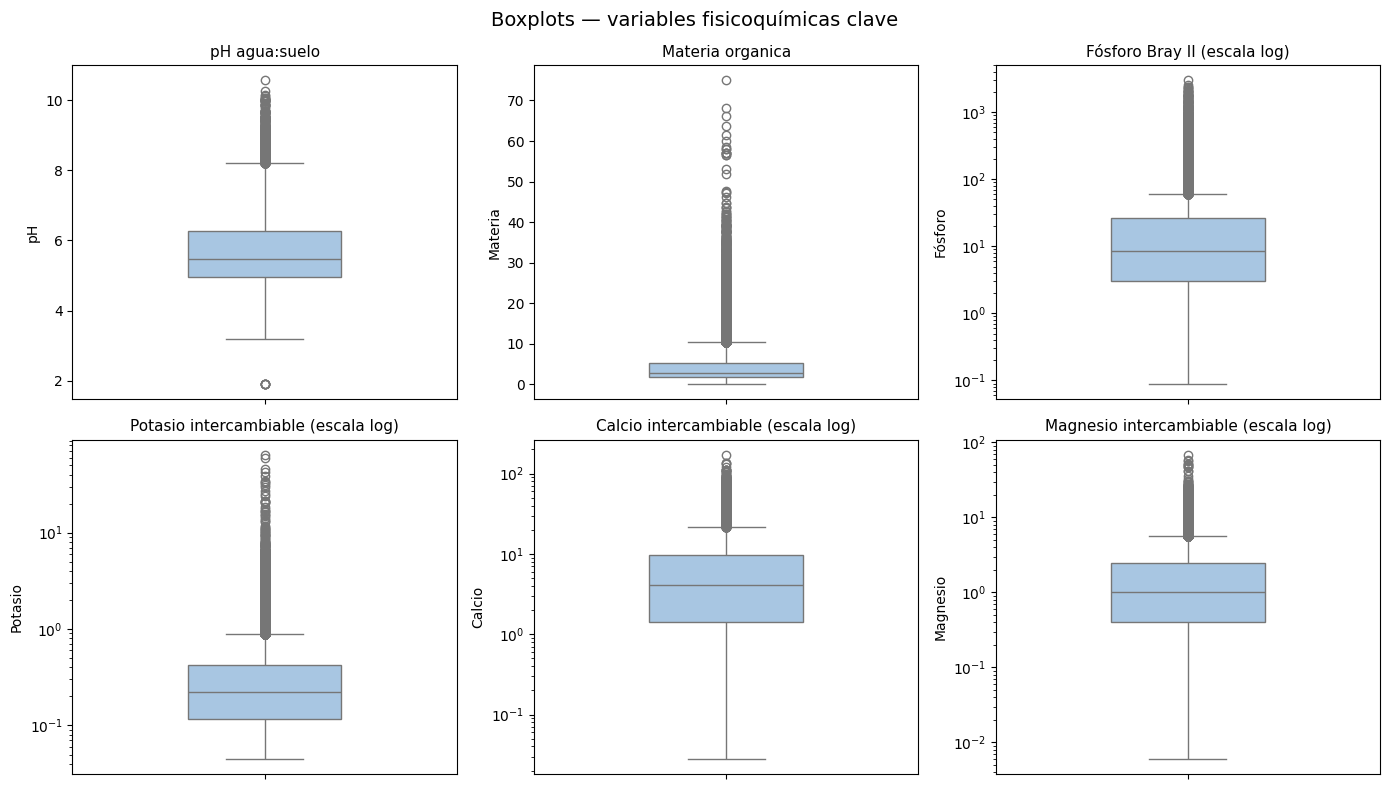

In [137]:
cols_iqr = ["pH agua:suelo", "Materia organica", "Fósforo Bray II",
            "Potasio intercambiable", "Calcio intercambiable", "Magnesio intercambiable"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, c in zip(axes.ravel(), cols_iqr):
    data = df[c].dropna()
    sns.boxplot(y=data, ax=ax, color="#9ec6ec", width=0.4)
    ax.set_title(c, fontsize=11)
    ax.set_ylabel(c.split()[0])

    # Escala log para los muy sesgados
    if data.max() / max(data.median(), 0.01) > 30:
        ax.set_yscale("log")
        ax.set_title(f"{c} (escala log)", fontsize=11)

fig.suptitle("Boxplots — variables fisicoquímicas clave", fontsize=14)
plt.tight_layout()
plt.show()

### Patrones generales

- **Materia orgánica es la única con sesgo extremo aún sin log** — vale la pena reportarla también en log o documentar que conviven dos poblaciones (suelos típicos vs. orgánicos de altura).
- **Hay muchísimos "outliers" estadísticos, pero no son errores** — son la cola natural de un fenómeno log-normal. Con ~92k muestras es esperable.
- **pH es el único parámetro "bien comportado" en escala lineal** (caja estrecha, pocos outliers) → tiene sentido físico, porque el pH ya es una escala log de [H⁺].

### Conclusión

Los boxplots **refuerzan los hallazgos del Paso 2**: suelos mayormente ácidos, con MO baja y deficiencias claras en P y K. La variabilidad sigue patrones log-normales típicos de variables químicas de suelo, y los outliers visibles son **estructurales, no errores** — reflejan la diversidad agroecológica real de Colombia.

## Paso 3 — Análisis espacial y por cultivo

### 3.1 Comparación entre departamentos (top 8 por n° de muestras)

In [138]:
top_dep = df["Departamento"].value_counts().head(8).index.tolist()
dep_stats = (df[df["Departamento"].isin(top_dep)]
             .groupby("Departamento")
             .agg(n=("Secuencial","count"),
                  pH_media=("pH agua:suelo","mean"),
                  pH_mediana=("pH agua:suelo","median"),
                  MO_media=("Materia organica","mean"),
                  MO_mediana=("Materia organica","median"))
             .round(2)
             .sort_values("n", ascending=False))
dep_stats

,n,pH_media,pH_mediana,MO_media,MO_mediana
Departamento,,,,,
CUNDINAMARCA,14016,5.63,5.39,7.23,5.19
VALLE DEL CAUCA,9244,6.32,6.17,4.44,3.13
META,8800,5.04,4.96,2.34,2.10
ANTIOQUIA,7907,5.38,5.25,6.40,3.79
NARIÑO,5961,5.99,5.82,5.11,3.52
BOYACÁ,5269,5.36,5.19,6.32,4.76
SANTANDER,4693,5.49,5.20,3.62,2.79
NORTE DE SANTANDER,3900,5.55,5.42,2.69,2.21


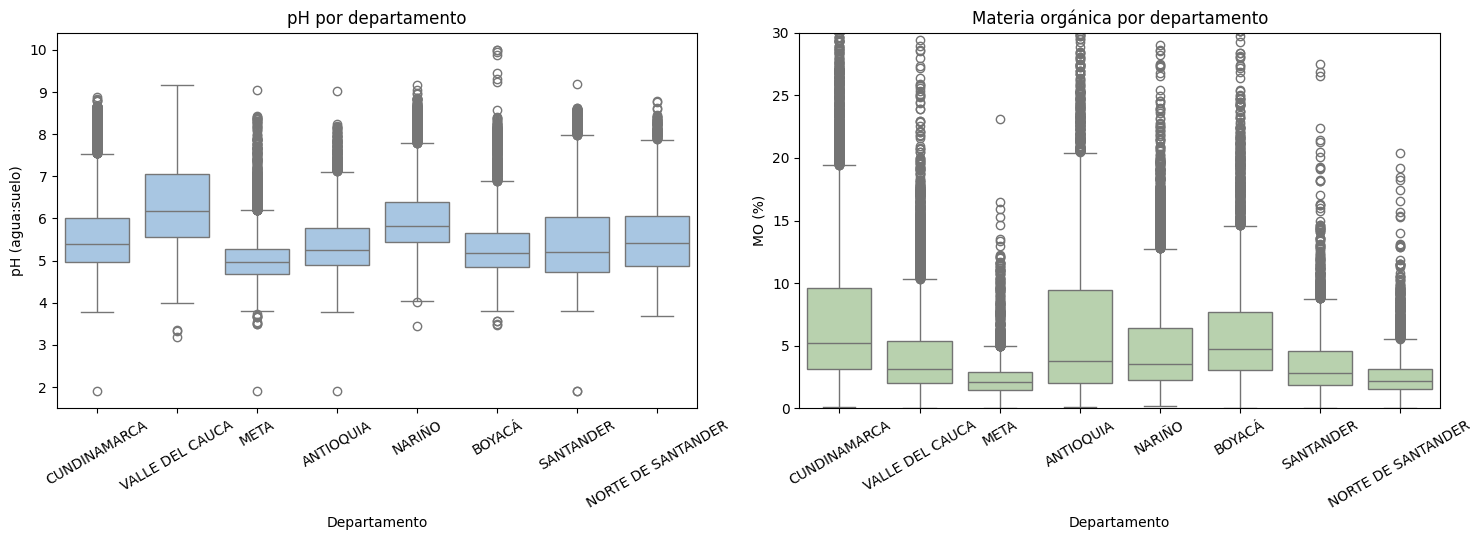

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sub = df[df["Departamento"].isin(top_dep)]
orden_dep = dep_stats.index.tolist()
sns.boxplot(data=sub, x="Departamento", y="pH agua:suelo", order=orden_dep,
            ax=axes[0], color="#9ec6ec")
axes[0].set_title("pH por departamento"); axes[0].set_ylabel("pH (agua:suelo)")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=sub, x="Departamento", y="Materia organica", order=orden_dep,
            ax=axes[1], color="#b6d7a8")
axes[1].set_title("Materia orgánica por departamento"); axes[1].set_ylabel("MO (%)")
axes[1].set_ylim(0,30); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

> **Patrón espacial:**
> - **Meta** y **Antioquia** tienen los suelos más ácidos (mediana pH ≈ 5.0–5.25) —
>   coherente con las llanuras de Oxisoles/Ultisoles altamente meteorizados y
>   los suelos lateríticos de Antioquia.
> - **Valle del Cauca** muestra el pH más alto (≈ 6.2) por la influencia de
>   sedimentos aluviales y la práctica intensiva de encalado en caña.
> - **Cundinamarca** y **Antioquia** acumulan más MO (climas fríos/altos andes).

### 3.2 Perfiles de fertilidad de los cinco cultivos más frecuentes

In [140]:
top_cult = (df[~df["Cultivo"].isin(["No Indica","No indica"])]["Cultivo"]
            .value_counts().head(5).index.tolist())
cult_stats = (df[df["Cultivo"].isin(top_cult)]
              .groupby("Cultivo")
              .agg(n=("Secuencial","count"),
                   pH=("pH agua:suelo","mean"),
                   MO=("Materia organica","mean"),
                   P=("Fósforo Bray II","median"),
                   K=("Potasio intercambiable","median"))
              .round(2)
              .sort_values("n", ascending=False))
cult_stats

,n,pH,MO,P,K
Cultivo,,,,,
Cacao,11104,5.34,2.76,5.05,0.13
Pastos,7542,5.75,5.68,11.46,0.28
Aguacate,5915,5.68,6.81,6.47,0.26
Pasto,5886,5.62,4.44,5.36,0.20
Café,5080,5.38,5.57,7.81,0.25


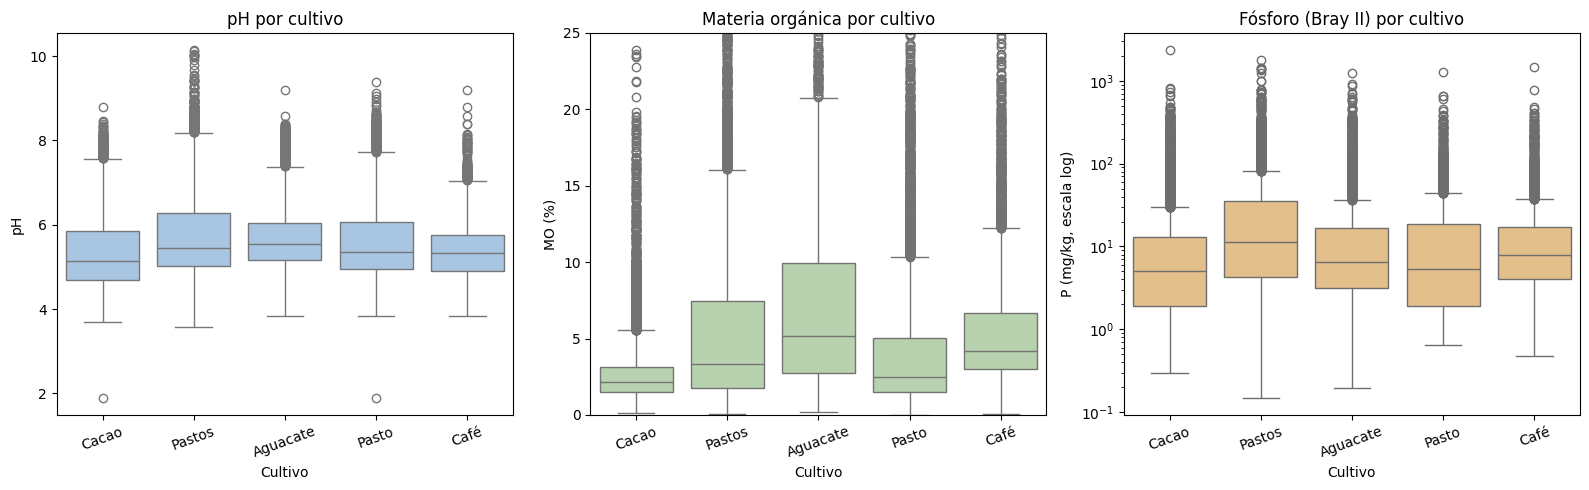

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sub_c = df[df["Cultivo"].isin(top_cult)]
sns.boxplot(data=sub_c, x="Cultivo", y="pH agua:suelo", order=top_cult, ax=axes[0], color="#9ec6ec")
axes[0].set_title("pH por cultivo"); axes[0].set_ylabel("pH"); axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=sub_c, x="Cultivo", y="Materia organica", order=top_cult, ax=axes[1], color="#b6d7a8")
axes[1].set_title("Materia orgánica por cultivo"); axes[1].set_ylabel("MO (%)")
axes[1].set_ylim(0,25); axes[1].tick_params(axis="x", rotation=20)
sns.boxplot(data=sub_c, x="Cultivo", y="Fósforo Bray II", order=top_cult, ax=axes[2], color="#f1c27d")
axes[2].set_yscale("log"); axes[2].set_title("Fósforo (Bray II) por cultivo")
axes[2].set_ylabel("P (mg/kg, escala log)"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

> **Lectura:**
> - **Cacao** se asocia con los pH más bajos (≈ 5.3) y P medianamente bajo,
>   consistente con su distribución en pie de monte amazónico y Catatumbo.
> - **Pastos/Pasto** muestran mayor variabilidad y P relativamente más alto
>   (manejo con fertilización en sistemas intensivos).
> - **Aguacate** acumula la MO más alta

### 3.3 Drenaje vs. materia orgánica

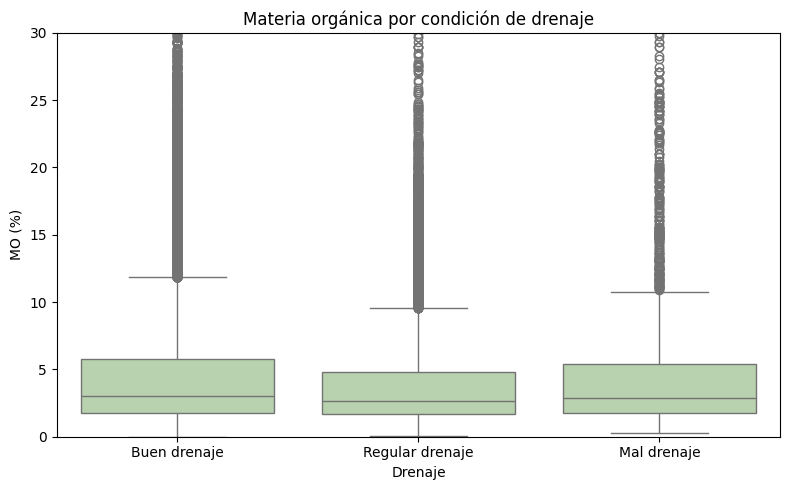

,count,mean,median,std
Drenaje,,,,
Buen drenaje,49806,4.77,2.99,4.77
Regular drenaje,14229,4.12,2.69,4.21
Mal drenaje,2667,4.84,2.85,5.48


In [142]:
drenaje_orden = ["Buen drenaje","Regular drenaje","Mal drenaje"]
sub_dr = df[df["Drenaje"].isin(drenaje_orden)]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sub_dr, x="Drenaje", y="Materia organica",
            order=drenaje_orden, ax=ax, color="#b6d7a8")
ax.set_title("Materia orgánica por condición de drenaje")
ax.set_ylabel("MO (%)"); ax.set_ylim(0,30)
plt.tight_layout(); plt.show()

sub_dr.groupby("Drenaje")["Materia organica"].agg(["count","mean","median","std"]).reindex(drenaje_orden).round(2)

Las medianas son similares (~2.7–3.0 %). El **buen drenaje** muestra ligeramente más MO en promedio, indicando que en este dataset la MO está más asociada a clima (altitud, temperatura) que a régimen hídrico local.

## Paso 4 — Relaciones entre nutrientes

### 4.1 Matriz de correlación (Spearman)

Usamos **Spearman** porque varias variables son log-normales con outliers extremos
(Pearson sería sensible a la cola).

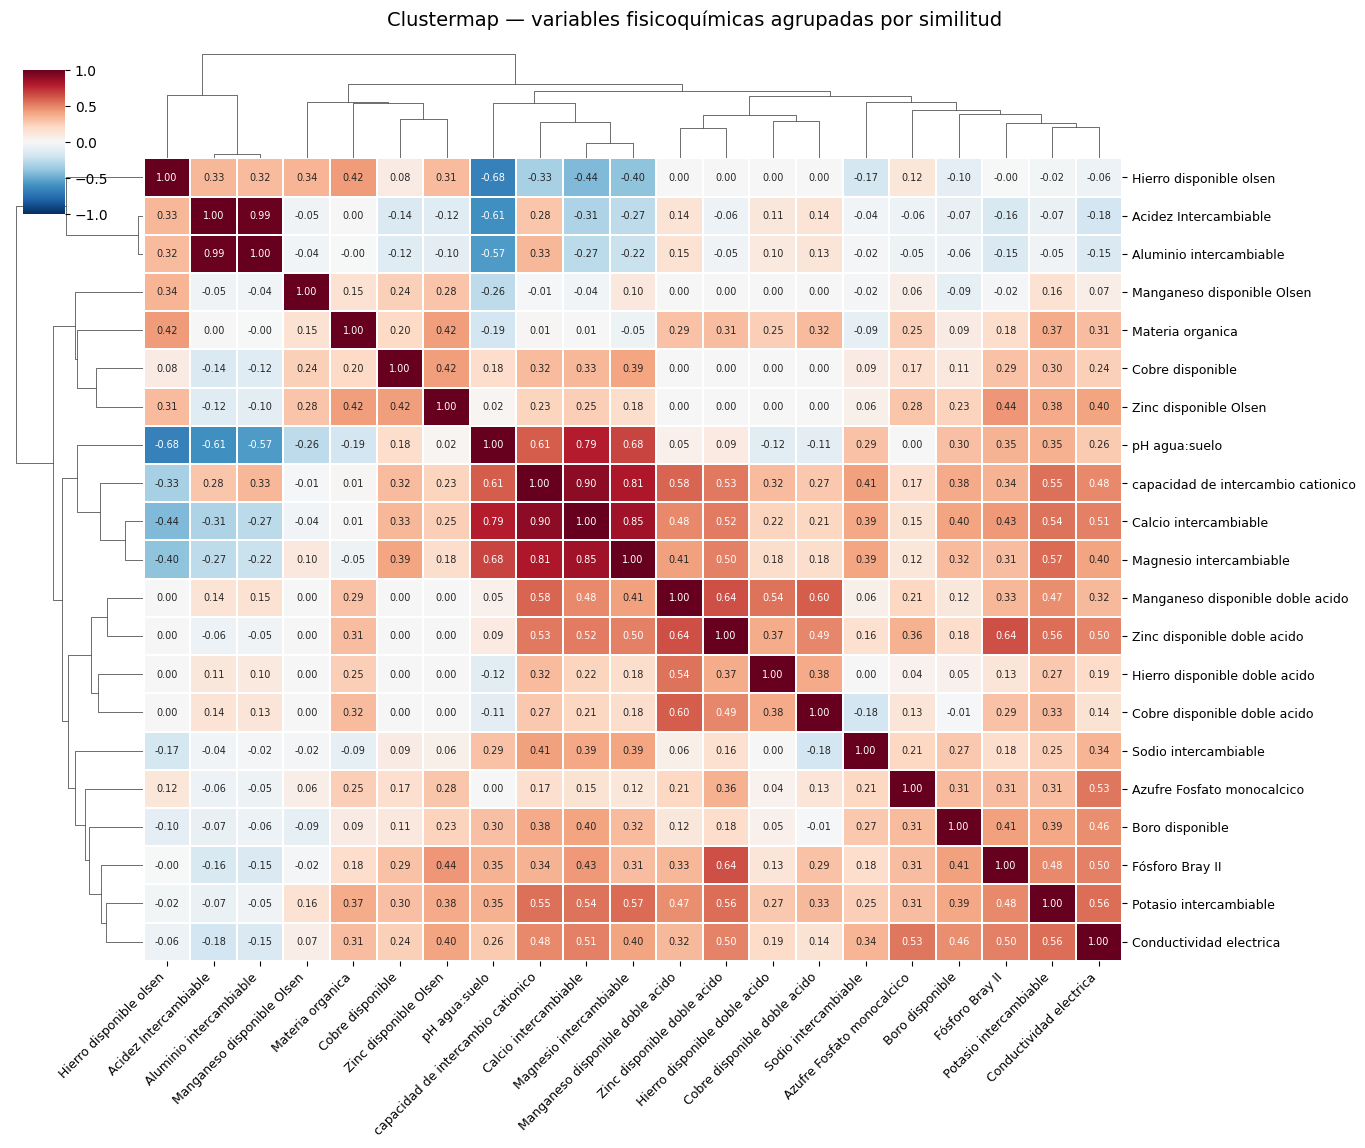

In [143]:
corr = df[num_cols].corr(method="spearman").fillna(0)

g = sns.clustermap(
    corr,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    figsize=(14, 12),
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.85, 0.03, 0.12),
    linewidths=0.3, linecolor="white",
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

g.fig.suptitle("Clustermap — variables fisicoquímicas agrupadas por similitud",
               y=1.02, fontsize=14)
plt.show()

### Conclusión del clustermap

El clustermap revela **tres grupos funcionales claros** de variables fisicoquímicas:

1. **Bloque de acidez** (Acidez, Al, Fe-Olsen) — fuertemente correlacionado internamente y opuesto al pH.
2. **Bloque de bases y fertilidad** (Ca, Mg, CIC, pH) — variables que se mueven juntas y definen suelos productivos.
3. **Bloque de iones móviles** (Na, S, B, P, K, CE) — agrupados por su naturaleza soluble; la conductividad eléctrica funciona como índice resumen.

Los métodos **"doble ácido"** quedan aislados, confirmando que aportan información redundante o poco comparable con los demás.

### 4.2. Análisis específico de la relación pH – disponibilidad de fósforo

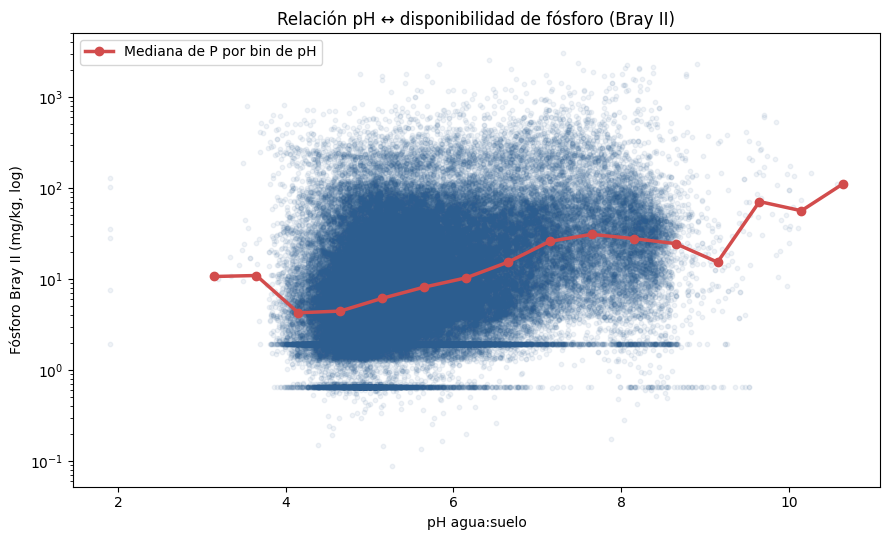

Spearman pH vs P = 0.347


In [144]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(df["pH agua:suelo"], df["Fósforo Bray II"],
           alpha=0.07, s=10, c="#2c5d8f")
ax.set_yscale("log")
ax.set_xlabel("pH agua:suelo")
ax.set_ylabel("Fósforo Bray II (mg/kg, log)")
ax.set_title("Relación pH ↔ disponibilidad de fósforo (Bray II)")

# Mediana de P por bin de pH (línea de tendencia)
bins = np.arange(df["pH agua:suelo"].min(), df["pH agua:suelo"].max() + 0.5, 0.5)
medians = (df.assign(ph_bin=pd.cut(df["pH agua:suelo"], bins=bins))
             .groupby("ph_bin", observed=True)["Fósforo Bray II"].median())
centers = [i.mid for i in medians.index]
ax.plot(centers, medians.values, color="#d24c4c", lw=2.5, marker="o",
        label="Mediana de P por bin de pH")

ax.legend()
plt.tight_layout()
plt.show()

rho = df[["pH agua:suelo", "Fósforo Bray II"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman pH vs P = {rho:.3f}")

In [145]:
# Bins de pH (puedes ajustar los cortes)
bins = [3, 4, 5, 6, 7, 8, 9, 11]
labels = ["3-4", "4-5", "5-6", "6-7", "7-8", "8-9", "9-11"]

df["pH_bin"] = pd.cut(df["pH agua:suelo"], bins=bins, labels=labels)

tabla = (
    df.groupby("pH_bin", observed=True)["Fósforo Bray II"]
      .agg(n="count", mediana="median", media="mean", q25=lambda s: s.quantile(.25),
           q75=lambda s: s.quantile(.75))
      .round(2)
)
print(tabla)

            n  mediana  media    q25    q75
pH_bin                                     
3-4       296     6.78  51.07   2.63  24.08
4-5     25081     4.54  16.22   1.94  12.10
5-6     37658     7.31  22.55   2.93  21.09
6-7     16906    13.26  36.86   5.10  35.99
7-8      7529    28.86  69.36  11.70  65.13
8-9      3667    26.66  52.64  11.34  48.24
9-11      125    33.75  80.68   8.57  95.91


### Relación pH ↔ disponibilidad de fósforo (Bray II)

La relación entre pH y disponibilidad de fósforo es **positiva y moderada (Spearman = 0.35)**: la mediana de P aumenta de forma sostenida conforme el suelo deja de ser ácido.

Este patrón confirma el comportamiento agronómico clásico: **el fósforo se fija en suelos ácidos por aluminio e hierro**, perdiendo disponibilidad para los cultivos. La correlación no es más fuerte porque la disponibilidad de P también depende de **materia orgánica, fertilización y mineralogía del suelo**.

**Lectura por rangos de pH:**

- **pH ácido (4 – 5):** P **mínimo** (mediana 4.54 mg/kg) → el fósforo se queda "fijado" por Al y Fe, no es asimilable. Es el rango más frecuente en el dataset (25 081 muestras).
- **pH neutro a ligeramente alcalino (7 – 8):** P **máximo práctico** (mediana 28.86 mg/kg) → zona óptima.
- **pH alcalino (> 8):** la mediana se mantiene alta (26 – 34 mg/kg). El rango 9–11 sólo agrupa 125 muestras, por lo que su tendencia ascendente debe interpretarse con cautela (pocos datos, mucha variabilidad).

**Implicación agronómica:** la mediana de P se multiplica **por más de 6** entre suelos ácidos (4.54 mg/kg) y suelos neutros (28.86 mg/kg). Este hallazgo explica por qué **encalar** (subir el pH de suelos ácidos) suele venir acompañado de mejor respuesta a la fertilización fosfórica.

In [146]:
def clasif_fert(v):
    if pd.isna(v):
        return "Sin dato"

    u = str(v).strip().upper()
    u = u.replace("_", " ")

    # ---------- 1) SIN DATO ----------
    patrones_sindato = [
        r"^NO\s+INDICA$",
        r"NO\s+SABE",
        r"NO\s+SE\s+SABE",
        r"NO\s+SE\s+CONOCE",
        r"NO\s+(SE\s+)?CONOCE",
        r"NO\s+DETERMINADO",
        r"NO\s+SE\s+TIENE\s+(DATO|INFORM)",
        r"NO\s+TENEMOS\s+INFORM",
        r"NO\s+SE\s+TIENE\s+INFORM",
        r"^N\s*O?\s*REGISTRA",
        r"^ND$",
        r"^NO\s+RESPONDE$",
        r"^$",
    ]
    if any(re.search(p, u) for p in patrones_sindato):
        return "Sin dato"

    # ---------- 2) NO FERTILIZADO ----------
    patrones_no = [
        r"^NO$",
        r"^NINGUNO$",
        # Verbos de aplicar/abonar/fertilizar/usar/hacer/poner (con typos comunes)
        r"NO\s+(SE\s+)?(LE\s+)?(HAN?\s+|HE\s+|S\s+HA\s+|S3E\s+)?(A\s+)?(APLI[CA]|ABON|FERTILIZ|REALIZ|USA|USO|UTILIZ|HECH|HACE|PUEST|PUEDT|PUSO|PONE)",
        # "NO HACE X AÑOS", "NO 4 AÑOS", "NO EN EL ULTIMO AÑO"
        r"^NO[\s,]+(HACE|EN|\d)",
        # "NO HAY PLAN DE FERTILIZACION"
        r"NO\s+HAY\s+(PLAN|FERTIL|ABON)",
        r"NO\s+TIENE",
        # "SIN ..."
        r"^SIN\s+(FERTIL|APLICAR|ABON)",
        r"NO\s+SE\s+ABON",
        # "No, nunca se ha aplicado" / "No, en pasto"
        r"^NO,",
    ]
    if any(re.search(p, u) for p in patrones_no):
        return "No fertilizado"

    # ---------- 3) Todo lo demás → fertilizante real ----------
    return "Fertilizado"

df["grupo_fert"] = df["Fertilizantes aplicados"].apply(clasif_fert)
print(df["grupo_fert"].value_counts())

grupo_fert
Sin dato          50349
No fertilizado    21699
Fertilizado       20690
Name: count, dtype: int64


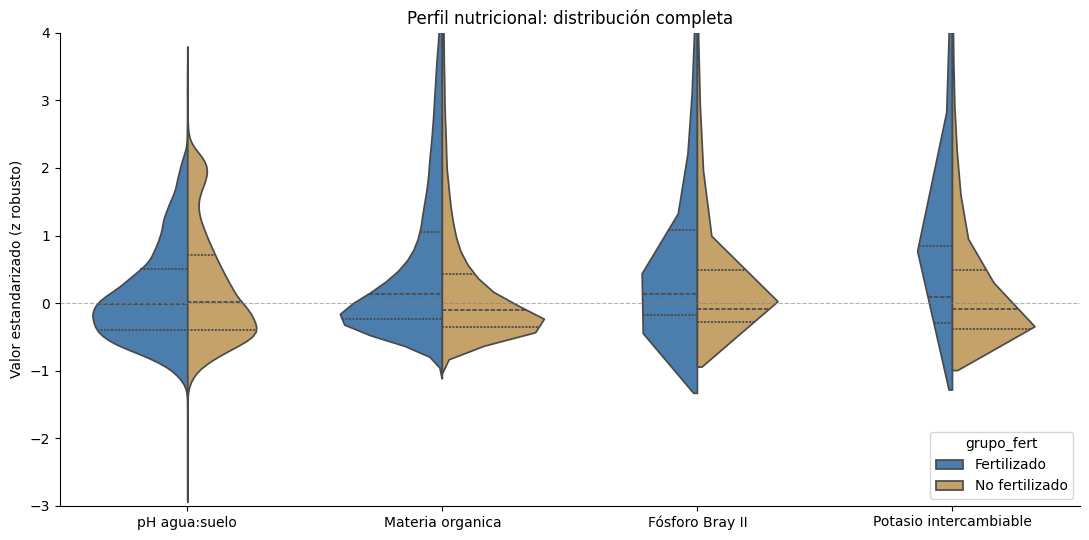

In [147]:
variables = ["pH agua:suelo", "Materia organica",
             "Fósforo Bray II", "Potasio intercambiable"]

# 1) Crear el DataFrame en formato largo
melt = (df[df["grupo_fert"].isin(["Fertilizado", "No fertilizado"])]
        .melt(id_vars="grupo_fert", value_vars=variables,
              var_name="variable", value_name="valor"))

# 2) Estandarizar con z robusto (mediana / IQR)
mediana = melt.groupby("variable")["valor"].transform("median")
q1 = melt.groupby("variable")["valor"].transform("quantile", q=0.25)
q3 = melt.groupby("variable")["valor"].transform("quantile", q=0.75)
melt["z"] = (melt["valor"] - mediana) / (q3 - q1)

# 3) Violinplot
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.violinplot(data=melt, x="variable", y="z", hue="grupo_fert",
               palette={"Fertilizado": "#3b7dbd", "No fertilizado": "#d4a55a"},
               split=True, inner="quartile", ax=ax)

ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.set_ylim(-3, 4)
ax.set_ylabel("Valor estandarizado (z robusto)")
ax.set_xlabel("")
ax.set_title("Perfil nutricional: distribución completa")
sns.despine()
plt.tight_layout()
plt.show()

## Interpretación del violin plot: perfil nutricional por grupo de fertilización

El gráfico compara la **distribución completa** de cuatro variables de suelo entre lotes **fertilizados** (azul) y **no fertilizados** (beige), usando **estandarización robusta** (z robusto = (x − mediana) / MAD). La línea punteada en y = 0 representa la mediana poblacional; valores positivos están por encima y negativos por debajo.

### Lectura por variable

| Variable | Fertilizado | No fertilizado | Diferencia entre grupos |
|---|---|---|---|
| **pH agua:suelo** | Centrado cerca de 0, ligera asimetría hacia arriba | Centrado cerca de 0, distribución similar | Casi nula — el pH no se ve afectado por la fertilización |
| **Materia orgánica** | Mediana ligeramente positiva, cola larga hacia valores altos | Concentrado por debajo de 0, cola corta | Moderada — fertilizados tienden a tener más MO |
| **Fósforo Bray II** | Distribución desplazada arriba, gran dispersión, cola larga | Muy concentrado cerca/por debajo de 0 | **Fuerte** — el P es la variable más sensible a la fertilización |
| **Potasio intercambiable** | Mediana claramente sobre 0, masa de datos arriba | Mediana negativa, masa concentrada abajo | **Fuerte** — separación clara entre grupos |

### Conclusiones

1. **La fertilización deja huella clara en P y K**, las dos variables que más directamente aportan los fertilizantes comerciales (NPK). Esto valida que el tratamiento "fertilizado" sí está modificando el perfil químico esperado.
2. **La materia orgánica responde de forma más sutil**, lo cual tiene sentido: la MO depende más del manejo a largo plazo (residuos, cobertura, labranza) que de una sola aplicación de fertilizante mineral.
3. **El pH es prácticamente inmune** a la categoría fertilizado/no fertilizado en este dataset. Para mover pH se necesitan enmiendas específicas (cal, azufre), no fertilización rutinaria.
4. Las **colas largas hacia arriba** en P y K sugieren que existen lotes con sobre-fertilización o acumulación histórica — algo a vigilar porque puede generar desbalances nutricionales

## Paso 5 — Componente de criterio libre

### Pregunta analítica

> **¿Es posible construir un Índice de Fertilidad Sintético (IFS) que combine los principales parámetros químicos del suelo en una sola métrica 0–100, y revelar así un ranking regional de fertilidad para los departamentos de Colombia?**

### Justificación agronómica

En la práctica, ningún parámetro por sí solo define la fertilidad de un suelo: un pH óptimo es inútil si el P es deficiente, y un alto contenido de Ca pierde valor si la CIC es baja. Los técnicos de extensión rural suelen evaluar la fertilidad de forma **integral**, combinando mentalmente varios indicadores.

Este Paso construye una versión **cuantitativa y reproducible** de esa evaluación, normalizando cada variable según rangos agronómicos de referencia para suelos tropicales (Marín, ICA, IGAC) y combinándolas en un índice ponderado. El objetivo no es producir un valor "absoluto" de fertilidad —ese concepto no existe—, sino un **score relativo** que permita comparar muestras y regiones bajo un mismo criterio.

### Variables incluidas y rangos óptimos de referencia

| Variable | Rango óptimo | Peso | Justificación |
|---|---|---|---|
| pH agua:suelo | 6.0 – 6.8 | 0.15 | Define disponibilidad de nutrientes |
| Materia orgánica (%) | ≥ 5 | 0.20 | Indicador integral de salud del suelo |
| Fósforo Bray II (mg/kg) | ≥ 30 | 0.20 | Macronutriente limitante en Colombia |
| Potasio intercambiable (cmol/kg) | ≥ 0.4 | 0.15 | Macronutriente esencial |
| Calcio intercambiable (cmol/kg) | ≥ 6 | 0.10 | Base mayoritaria |
| Capacidad de intercambio catiónico (cmol/kg) | ≥ 15 | 0.20 | Capacidad de retener nutrientes |

El score de cada variable se normaliza linealmente entre 0 (deficiente) y 1 (óptimo o superior), y el IFS final es el promedio ponderado, escalado a 0–100.

In [148]:
import numpy as np
import pandas as pd

# 1) Rangos óptimos: (mínimo deficiente, óptimo o superior)
rangos = {
    "pH agua:suelo":                          (4.0, 6.5),
    "Materia organica":                       (0.0, 5.0),
    "Fósforo Bray II":                        (0.0, 30.0),
    "Potasio intercambiable":                 (0.0, 0.4),
    "Calcio intercambiable":                  (0.0, 6.0),
    "capacidad de intercambio cationico":     (0.0, 15.0),
}

# 2) Pesos agronómicos (suman 1.0)
pesos = {
    "pH agua:suelo":                          0.15,
    "Materia organica":                       0.20,
    "Fósforo Bray II":                        0.20,
    "Potasio intercambiable":                 0.15,
    "Calcio intercambiable":                  0.10,
    "capacidad de intercambio cationico":     0.20,
}

# 3) Caso especial pH: óptimo en 6.0–6.8, penaliza desviación hacia ambos lados
def score_ph(x):
    if pd.isna(x): return np.nan
    if 6.0 <= x <= 6.8: return 1.0
    if x < 6.0: return max(0, (x - 4.0) / (6.0 - 4.0))   # 4.0 → 0,  6.0 → 1
    return max(0, 1 - (x - 6.8) / (9.0 - 6.8))            # 6.8 → 1,  9.0 → 0

# 4) Para el resto: lineal entre min_def y óptimo, saturando en 1
def score_lineal(x, lo, hi):
    if pd.isna(x): return np.nan
    return np.clip((x - lo) / (hi - lo), 0, 1)

# 5) Calcular el score de cada variable
scores = pd.DataFrame(index=df.index)
scores["pH agua:suelo"] = df["pH agua:suelo"].apply(score_ph)
for var, (lo, hi) in rangos.items():
    if var == "pH agua:suelo": continue
    scores[var] = df[var].apply(lambda x: score_lineal(x, lo, hi))

# 6) Índice de Fertilidad Sintético (IFS): promedio ponderado × 100
peso_total = sum(pesos.values())
ifs = sum(scores[v] * w for v, w in pesos.items()) / peso_total * 100
df["IFS"] = ifs

# Vista rápida
print(df["IFS"].describe().round(2))

count    91198.00
mean        56.68
std         21.15
min          7.51
25%         40.12
50%         57.76
75%         73.17
max        100.00
Name: IFS, dtype: float64


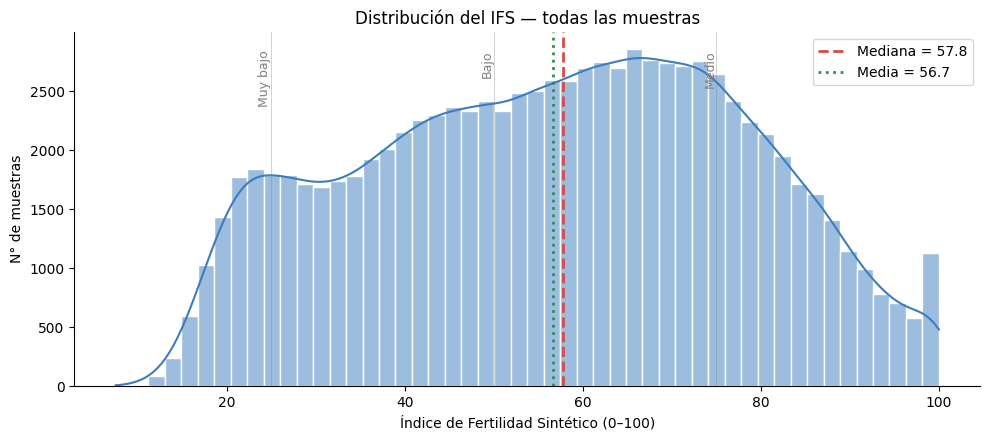

In [149]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(df["IFS"].dropna(), bins=50, kde=True,
             color="#3b7dbd", edgecolor="white", ax=ax)
ax.axvline(df["IFS"].median(), color="#d24c4c", lw=2, ls="--",
           label=f"Mediana = {df['IFS'].median():.1f}")
ax.axvline(df["IFS"].mean(), color="#2d8f4e", lw=2, ls=":",
           label=f"Media = {df['IFS'].mean():.1f}")

# Bandas interpretativas
for x, txt in [(25, "Muy bajo"), (50, "Bajo"), (75, "Medio")]:
    ax.axvline(x, color="gray", lw=0.6, ls="-", alpha=0.4)
    ax.text(x, ax.get_ylim()[1]*0.95, txt, rotation=90,
            ha="right", va="top", color="gray", fontsize=9)

ax.set_xlabel("Índice de Fertilidad Sintético (0–100)")
ax.set_ylabel("N° de muestras")
ax.set_title("Distribución del IFS — todas las muestras")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [150]:
ranking = (df.groupby("Departamento")["IFS"]
             .agg(["count", "median", "mean"])
             .query("count >= 100")           # mínimo 100 muestras
             .sort_values("median", ascending=False)
             .round(2))

print(f"Top 10 departamentos más fértiles:\n{ranking.head(10)}\n")
print(f"Top 10 departamentos menos fértiles:\n{ranking.tail(10)}")

Top 10 departamentos más fértiles:
                 count  median   mean
Departamento                         
VALLE DEL CAUCA   9207   70.35  68.36
ATLÁNTICO          703   69.88  66.59
LA GUAJIRA        3003   68.94  67.10
CUNDINAMARCA     13790   67.51  66.88
NARIÑO            5822   66.56  66.15
BOGOTÁ, D.C.       583   66.48  63.58
BOYACÁ            5151   66.03  65.03
SUCRE              812   65.67  60.50
CÓRDOBA           2266   65.37  62.13
MAGDALENA         1683   64.13  61.55

Top 10 departamentos menos fértiles:
              count  median   mean
Departamento                      
CAUCA          2359   52.73  53.12
SANTANDER      4586   52.38  53.80
CHOCÓ           134   42.65  47.62
PUTUMAYO       3044   39.93  42.97
ARAUCA         1102   37.50  39.47
CASANARE       1909   33.85  37.08
META           8641   31.88  35.43
CAQUETÁ        2197   28.16  31.58
GUAVIARE        913   26.36  28.46
VICHADA         336   18.71  20.48


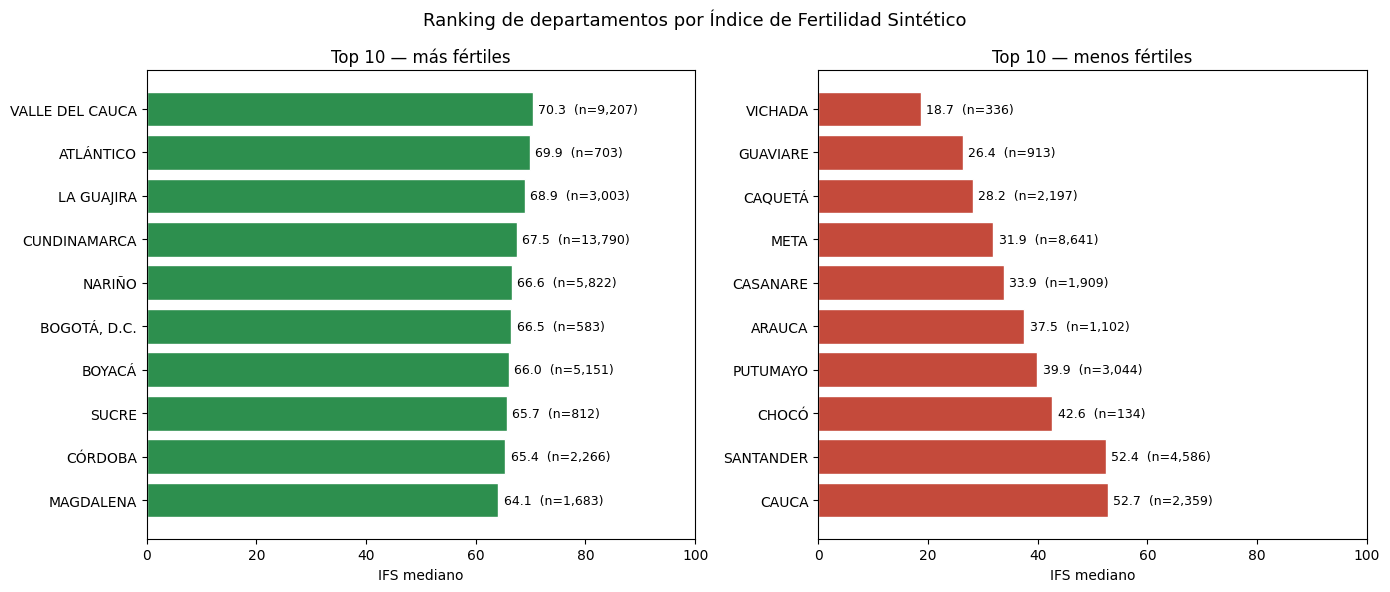

In [151]:
top10 = ranking.head(10).iloc[::-1]
bot10 = ranking.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10.index, top10["median"], color="#2d8f4e", edgecolor="white")
axes[0].set_title("Top 10 — más fértiles")
axes[0].set_xlabel("IFS mediano")
axes[0].set_xlim(0, 100)
for i, (v, n) in enumerate(zip(top10["median"], top10["count"])):
    axes[0].text(v + 1, i, f"{v:.1f}  (n={int(n):,})", va="center", fontsize=9)

axes[1].barh(bot10.index, bot10["median"], color="#c44a3b", edgecolor="white")
axes[1].set_title("Top 10 — menos fértiles")
axes[1].set_xlabel("IFS mediano")
axes[1].set_xlim(0, 100)
for i, (v, n) in enumerate(zip(bot10["median"], bot10["count"])):
    axes[1].text(v + 1, i, f"{v:.1f}  (n={int(n):,})", va="center", fontsize=9)

plt.suptitle("Ranking de departamentos por Índice de Fertilidad Sintético", fontsize=13)
plt.tight_layout()
plt.show()

### Resultados — Ranking departamental por IFS

El gráfico muestra los 10 departamentos con mayor y menor Índice de Fertilidad Sintético (IFS) entre los que tienen cobertura suficiente de muestras. Tres patrones saltan a la vista:

**1. Brecha enorme entre extremos.** El IFS mediano va de **70.3 en Valle del Cauca** hasta **18.7 en Vichada** — una diferencia de 51 puntos sobre una escala de 100. Esto confirma que la fertilidad de los suelos colombianos no es uniforme; depende fuertemente de la región geográfica.

**2. Los suelos más fértiles están en valles, sabanas interiores y la costa Caribe.** Los 10 departamentos del ranking superior comparten una característica clave: predominan **suelos aluviales o sedimentarios recientes** (Valle del Cauca, Atlántico, La Guajira, Magdalena, Córdoba, Sucre) o **suelos andinos en altiplanos** (Cundinamarca, Boyacá, Bogotá, Nariño). Estos suelos retienen mejor las bases intercambiables (Ca, Mg, K), tienen mayor CIC y han sido menos lavados por la lluvia intensa.

**3. Los suelos menos fértiles se concentran en la Orinoquia, la Amazonia y el Chocó.** El ranking inferior está dominado por departamentos del **trópico húmedo** (Vichada, Guaviare, Caquetá, Meta, Casanare, Arauca, Putumayo, Chocó). Son suelos ácidos, pobres en P y con menor CIC.

### Interpretación

El IFS no solo describe — **explica un patrón geográfico** que coincide con la frontera agrícola comercial del país. Los departamentos con IFS alto concentran la agroindustria intensiva (caña en el Valle, papa y hortalizas en el altiplano cundi-boyacense, banano en Magdalena y La Guajira), mientras que los de IFS bajo corresponden a la **frontera agrícola en expansión** sobre suelos marginales: ganadería extensiva en los Llanos, cultivos de subsistencia y coca en la Amazonia. Esto sugiere que la productividad agrícola colombiana está **limitada estructuralmente por la fertilidad de los suelos donde se está expandiendo**, no solo por factores técnicos o económicos.
